In [ ]:
!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install -q torch-geometric open3d huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 32.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.2 MB/s eta 0:00:00


In [ ]:
import os, glob, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool, GraphNorm
from huggingface_hub import hf_hub_download

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue

Device: cuda


In [ ]:
def pcd_to_pyg(ply_path, num_points=1024, mesh_depth=7, max_nodes=2048):
    pcd = o3d.io.read_point_cloud(ply_path)
    print(f"Raw points: {len(pcd.points)}")

    # subsample
    if len(pcd.points) > num_points:
        pcd = pcd.farthest_point_down_sample(num_points)
    print(f"After subsample: {len(pcd.points)}")

    # normalise to unit sphere
    pts = np.asarray(pcd.points, dtype=np.float32)
    pts -= pts.mean(axis=0)
    scale = np.linalg.norm(pts, axis=1).max()
    pts /= scale
    pcd.points = o3d.utility.Vector3dVector(pts)

    # normals (required for Poisson)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )
    pcd.orient_normals_consistent_tangent_plane(30)

    # Poisson reconstruction
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd, depth=mesh_depth
    )

    # prune low-density artefacts
    dens = np.asarray(densities)
    mesh.remove_vertices_by_mask(dens < np.quantile(dens, 0.05))
    mesh.remove_degenerate_triangles()
    mesh.remove_duplicated_vertices()

    verts = np.asarray(mesh.vertices,  dtype=np.float32)
    faces = np.asarray(mesh.triangles, dtype=np.int64)
    print(f"Mesh verts: {len(verts)}  faces: {len(faces)}")

    # cap nodes
    if len(verts) > max_nodes:
        idx    = np.random.choice(len(verts), max_nodes, replace=False)
        idx_s  = set(idx.tolist())
        remap  = {o: n for n, o in enumerate(sorted(idx_s))}
        verts  = verts[sorted(idx_s)]
        faces  = np.array(
            [[remap[v] for v in f] for f in faces
             if f[0] in idx_s and f[1] in idx_s and f[2] in idx_s],
            dtype=np.int64
        )
    print(f"After cap  verts: {len(verts)}  faces: {len(faces)}")

    # edge_index from triangles (undirected)
    edges = set()
    for a, b, c in faces:
        edges.update([(a,b),(b,a),(b,c),(c,b),(a,c),(c,a)])
    edge_index = torch.tensor(sorted(edges), dtype=torch.long).t().contiguous()

    x = torch.tensor(verts, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)




In [ ]:
os.makedirs("data", exist_ok=True)

zip_path = hf_hub_download(
    repo_id="BGLab/MaizeField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="data"
)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("data")

ply_files = sorted(glob.glob("data/**/*.ply", recursive=True))
print(f"Found {len(ply_files)} files")

graphs = []
for i, fp in enumerate(ply_files):
    g = pcd_to_pyg(fp)          # same function from single-sample cell 4
    if g is not None:
        graphs.append(g)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(ply_files)}  valid={len(graphs)}")

print(f"\n✅ Valid graphs: {len(graphs)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Found 1045 files
Raw points: 10000
After subsample: 1024
Mesh verts: 4944  faces: 9684
After cap  verts: 2048  faces: 653
Raw points: 10000
After subsample: 1024
Mesh verts: 5437  faces: 10643
After cap  verts: 2048  faces: 610
Raw points: 10000
After subsample: 1024
Mesh verts: 5139  faces: 10096
After cap  verts: 2048  faces: 634
Raw points: 10000
After subsample: 1024
Mesh verts: 5347  faces: 10472
After cap  verts: 2048  faces: 589
Raw points: 10000
After subsample: 1024
Mesh verts: 4769  faces: 9364
After cap  verts: 2048  faces: 715
Raw points: 10000
After subsample: 1024
Mesh verts: 5645  faces: 11105
After cap  verts: 2048  faces: 550
Raw points: 10000
After subsample: 1024
Mesh verts: 5202  faces: 10230
After cap  verts: 2048  faces: 610
Raw points: 10000
After subsample: 1024
Mesh verts: 5226  faces: 10296
After cap  verts: 2048  faces: 622
Raw points: 10000
After subsample: 1024
Mesh verts: 5223  faces: 10248
After cap  verts: 2048  faces: 608
Raw points: 10000
After subsamp

In [ ]:
import random
from torch_geometric.loader import DataLoader

random.shuffle(graphs)
n_val        = max(1, int(len(graphs) * 0.15))
val_graphs   = graphs[:n_val]
train_graphs = graphs[n_val:]
print(f"Train: {len(train_graphs)}  Val: {len(val_graphs)}")

train_loader = DataLoader(train_graphs, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_graphs,   batch_size=4, shuffle=False, num_workers=0)

Train: 889  Val: 156


In [ ]:
class MeshEdgeConv(MessagePassing):
    def __init__(self, in_ch, out_ch):
        super().__init__(aggr='max')
        self.mlp = nn.Sequential(
            nn.Linear(in_ch * 2, out_ch),
            nn.LeakyReLU(0.2),
            nn.Linear(out_ch, out_ch),
        )
        self.norm = GraphNorm(out_ch)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x, edge_index, batch=None):
        out = self.propagate(edge_index, x=x)
        out = self.norm(out, batch)
        return F.leaky_relu(out + self.res(x), 0.2)

    def message(self, x_i, x_j):
        return self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))


class Encoder(nn.Module):
    def __init__(self, in_ch=3, hidden=64, latent=128, n_layers=3):
        super().__init__()
        dims        = [in_ch] + [hidden] * n_layers
        self.layers = nn.ModuleList([MeshEdgeConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.fc_mu  = nn.Linear(hidden * n_layers * 2, latent)
        self.fc_lv  = nn.Linear(hidden * n_layers * 2, latent)

    def forward(self, x, edge_index, batch):
        feats = []
        for layer in self.layers:
            x = layer(x, edge_index, batch)
            feats.append(x)
        h = torch.cat(feats, dim=-1)
        g = torch.cat([global_mean_pool(h, batch), global_max_pool(h, batch)], dim=-1)
        return self.fc_mu(g), self.fc_lv(g)


class Decoder(nn.Module):
    """
    Key fix: decoder input = proj(z)[per node]  CAT  original_x
    This gives every node a UNIQUE seed so EdgeConv can
    differentiate nodes and won't collapse to a single point.
    """
    def __init__(self, latent=128, hidden=64, out_ch=3, n_layers=3):
        super().__init__()
        # latent + 3 (original xyz concatenated as positional seed)
        self.proj   = nn.Sequential(nn.Linear(latent + 3, hidden), nn.LeakyReLU(0.2))
        self.layers = nn.ModuleList([MeshEdgeConv(hidden, hidden) for _ in range(n_layers)])
        self.head   = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, out_ch),
        )

    def forward(self, z, x_in, edge_index, batch):
        # broadcast latent to each node, then concat original coords as seed
        node_feat = torch.cat([z[batch], x_in], dim=-1)  # (N, latent+3)
        x = self.proj(node_feat)
        for layer in self.layers:
            x = layer(x, edge_index, batch)
        return self.head(x)


class DGCNN_MeshAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, data):
        mu, lv = self.encoder(data.x, data.edge_index, data.batch)
        z      = mu + torch.exp(0.5 * lv) * torch.randn_like(mu) if self.training else mu
        x_hat  = self.decoder(z, data.x, data.edge_index, data.batch)
        return x_hat, mu, lv


model = DGCNN_MeshAE().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 177,219


In [ ]:
def chamfer(pred, target):
    dist2 = ((pred.unsqueeze(1) - target.unsqueeze(0)) ** 2).sum(-1)
    return dist2.min(1).values.mean() + dist2.min(0).values.mean()

In [ ]:
def chamfer_batch(pred, target, batch_idx):
    """Mean CD over all graphs in a PyG batch."""
    total    = torch.tensor(0.0, device=pred.device)
    n_graphs = int(batch_idx.max().item()) + 1
    for g in range(n_graphs):
        mask    = batch_idx == g
        dist2   = ((pred[mask].unsqueeze(1) - target[mask].unsqueeze(0)) ** 2).sum(-1)
        total  += dist2.min(1).values.mean() + dist2.min(0).values.mean()
    return total / n_graphs

In [ ]:
import wandb
wandb.login()

run = wandb.init(
    project = "maize-dgcnn-mesh-ae-log",
    name    = "full-dataset-run",
    config  = {
        "epochs": 100, "batch_size": 4, "lr": 1e-3,
        "hidden": 64,  "latent": 128,  "beta": 0.0,
    }
)
wandb.watch(model, log="all", log_freq=50)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shantanugupta2004 (shantanugupta2004-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# model, chamfer loss, MeshEdgeConv — all same as single-sample version

optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=100, eta_min=1e-5)

best_val_cd = float('inf')
EPOCHS = 100

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):

    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    t_cd = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimiser.zero_grad()

        x_hat, mu, lv = model(batch)
        loss = chamfer_batch(x_hat, batch.x, batch.batch)   # see below

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        t_cd += loss.item()

    scheduler.step()
    t_cd /= len(train_loader)

    # ── val ────────────────────────────────────────────────────────────────
    model.eval()
    v_cd = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            x_hat, mu, lv = model(batch)
            v_cd += chamfer_batch(x_hat, batch.x, batch.batch).item()
    v_cd /= len(val_loader)

    train_losses.append(t_cd)
    val_losses.append(v_cd)

    wandb.log({"train/cd": t_cd, "val/cd": v_cd,
               "lr": scheduler.get_last_lr()[0], "epoch": epoch})

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  Train CD={t_cd:.5f}  Val CD={v_cd:.5f}")

    if v_cd < best_val_cd:
        best_val_cd = v_cd
        torch.save(model.state_dict(), "best_dgcnn_mesh.pt")
        wandb.save("best_dgcnn_mesh.pt")

print(f"\n🏆 Best val CD: {best_val_cd:.5f}")
# wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch   1  Train CD=0.10502  Val CD=0.01894
Epoch  10  Train CD=0.00429  Val CD=0.00432
Epoch  20  Train CD=0.00340  Val CD=0.00343
Epoch  30  Train CD=0.00302  Val CD=0.00294
Epoch  40  Train CD=0.00286  Val CD=0.00277
Epoch  50  Train CD=0.00276  Val CD=0.00267
Epoch  60  Train CD=0.00262  Val CD=0.00267
Epoch  70  Train CD=0.00253  Val CD=0.00238
Epoch  80  Train CD=0.00245  Val CD=0.00234
Epoch  90  Train CD=0.00240  Val CD=0.00232
Epoch 100  Train CD=0.00239  Val CD=0.00229

🏆 Best val CD: 0.00229


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
lr,██████▇▇▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
train/cd,█▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/cd,█▇▅▄▃▃▄▃▂▂▄▂▂▂▂▂▁▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
lr,1e-05
train/cd,0.00239
val/cd,0.00229


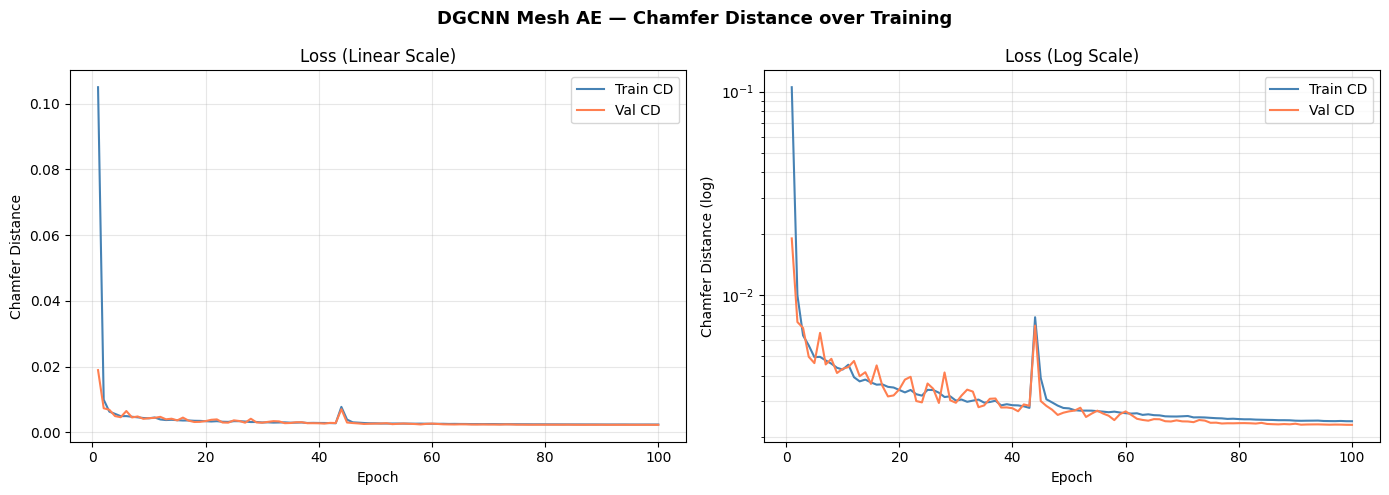

Best val CD: 0.002292 at epoch 100


In [ ]:
# ── Train & Val Loss — Linear + Log Scale ───────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(train_losses) + 1)

for ax, yscale, title in zip(
    axes,
    ['linear', 'log'],
    ['Loss (Linear Scale)', 'Loss (Log Scale)']
):
    ax.plot(epochs_x, train_losses, label='Train CD', color='steelblue', linewidth=1.5)
    ax.plot(epochs_x, val_losses,   label='Val CD',   color='coral',     linewidth=1.5)
    ax.set_yscale(yscale)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Chamfer Distance' + (' (log)' if yscale == 'log' else ''))
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('DGCNN Mesh AE — Chamfer Distance over Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curve_log.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val CD: {min(val_losses):.6f} at epoch {np.argmin(val_losses) + 1}')


Error: You must call wandb.init() before wandb.log()

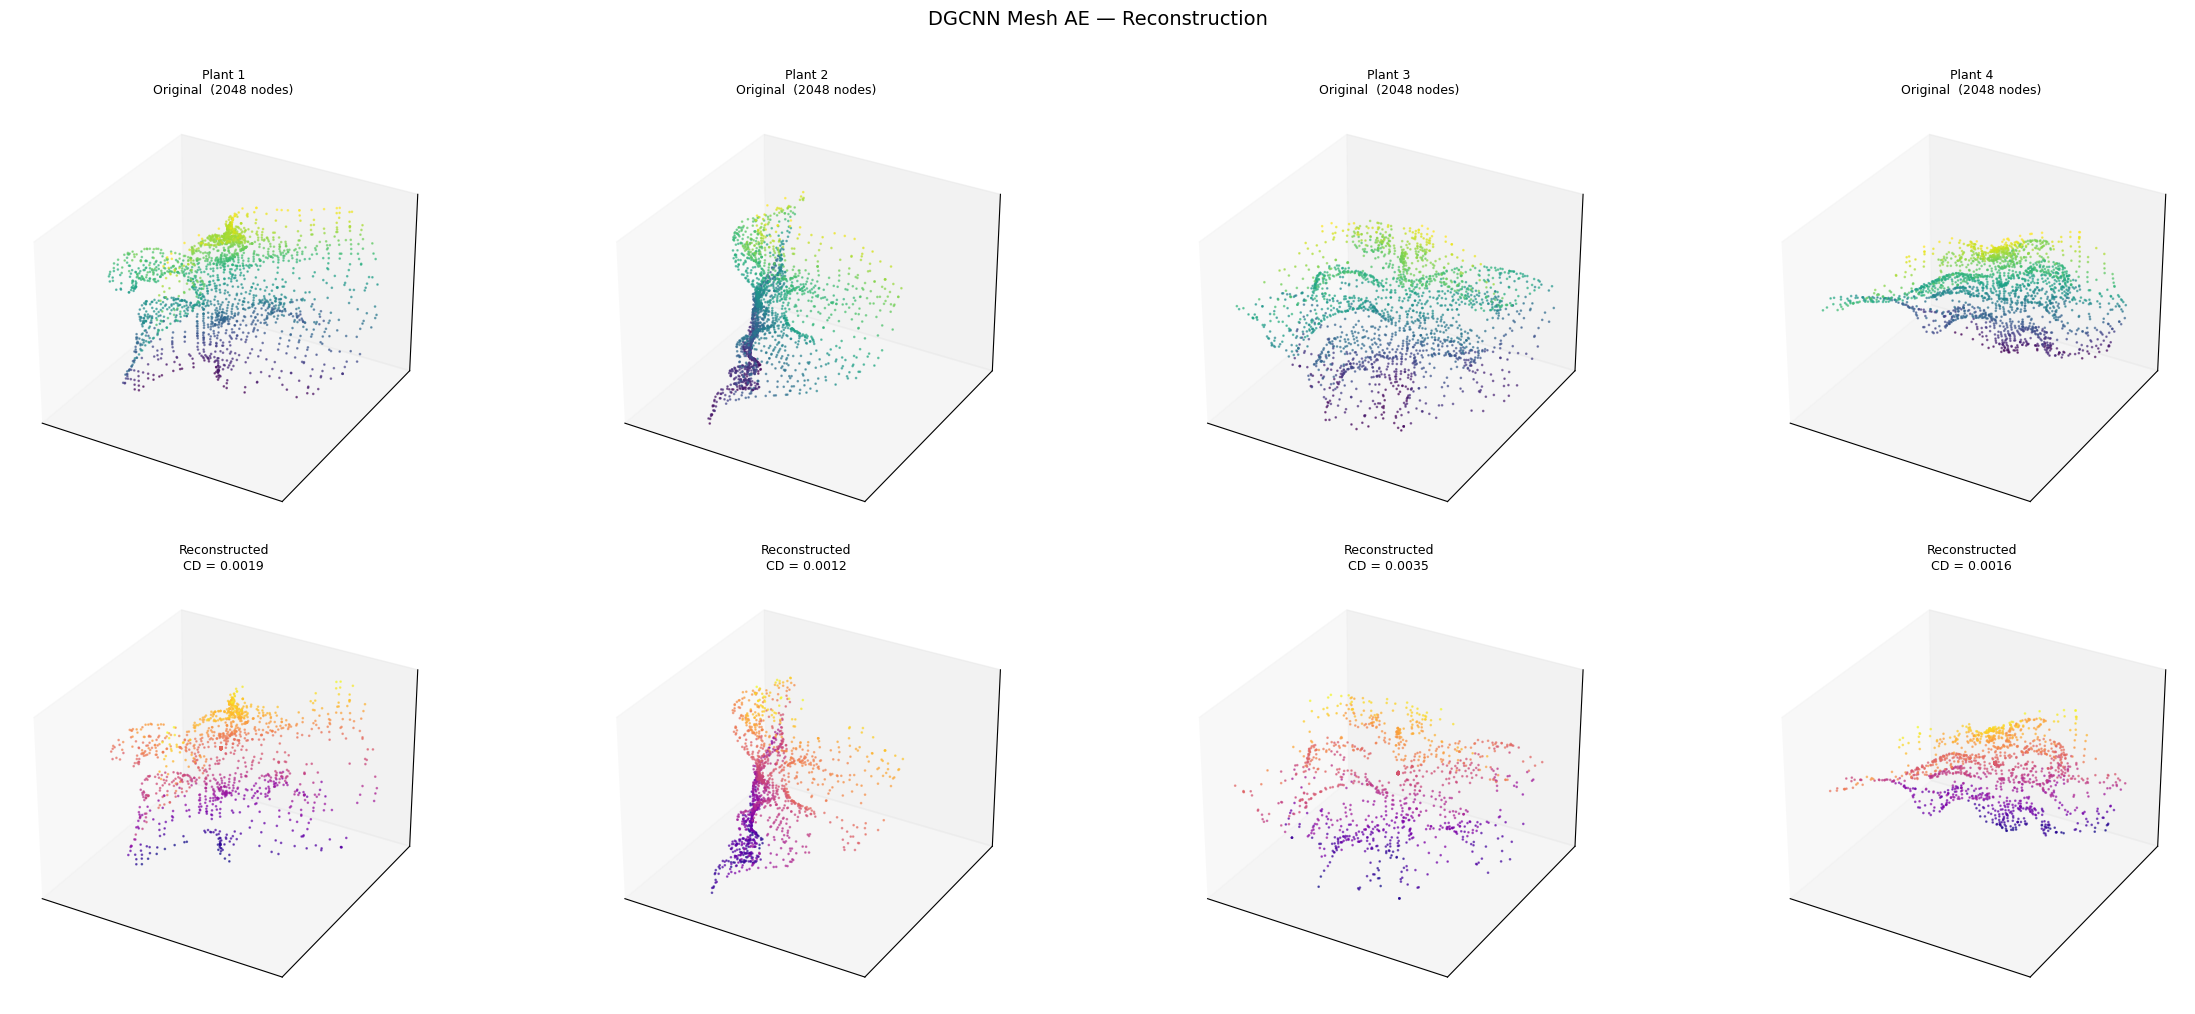

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# load best checkpoint
model.load_state_dict(torch.load("best_dgcnn_mesh.pt", map_location=device))
model.eval()

# pick 4 samples from val set (or fewer if val is small)
n_show  = min(4, len(val_graphs))
samples = val_graphs[:n_show]

fig = plt.figure(figsize=(6 * n_show, 10))
fig.suptitle("DGCNN Mesh AE — Reconstruction", fontsize=14, y=1.01)

for col, g in enumerate(samples):
    # single graph → batch vector = all zeros
    g_dev       = g.clone().to(device)
    g_dev.batch = torch.zeros(g_dev.num_nodes, dtype=torch.long, device=device)

    with torch.no_grad():
        x_hat, _, _ = model(g_dev)

    orig  = g.x.numpy()
    recon = x_hat.cpu().numpy()
    cd    = chamfer(x_hat, g_dev.x).item()

    # ── original ───────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(2, n_show, col + 1, projection='3d')
    ax1.scatter(orig[:,0], orig[:,1], orig[:,2],
                s=0.8, alpha=0.6, c=orig[:,2], cmap='viridis')
    ax1.set_title(f"Plant {col+1}\nOriginal  ({orig.shape[0]} nodes)", fontsize=9)
    ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

    # ── reconstruction ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, n_show, n_show + col + 1, projection='3d')
    ax2.scatter(recon[:,0], recon[:,1], recon[:,2],
                s=0.8, alpha=0.6, c=recon[:,2], cmap='plasma')
    ax2.set_title(f"Reconstructed\nCD = {cd:.4f}", fontsize=9)
    ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150, bbox_inches='tight')
wandb.log({"reconstruction": wandb.Image("reconstruction.png")})
plt.show()
print(f"Saved reconstruction.png")

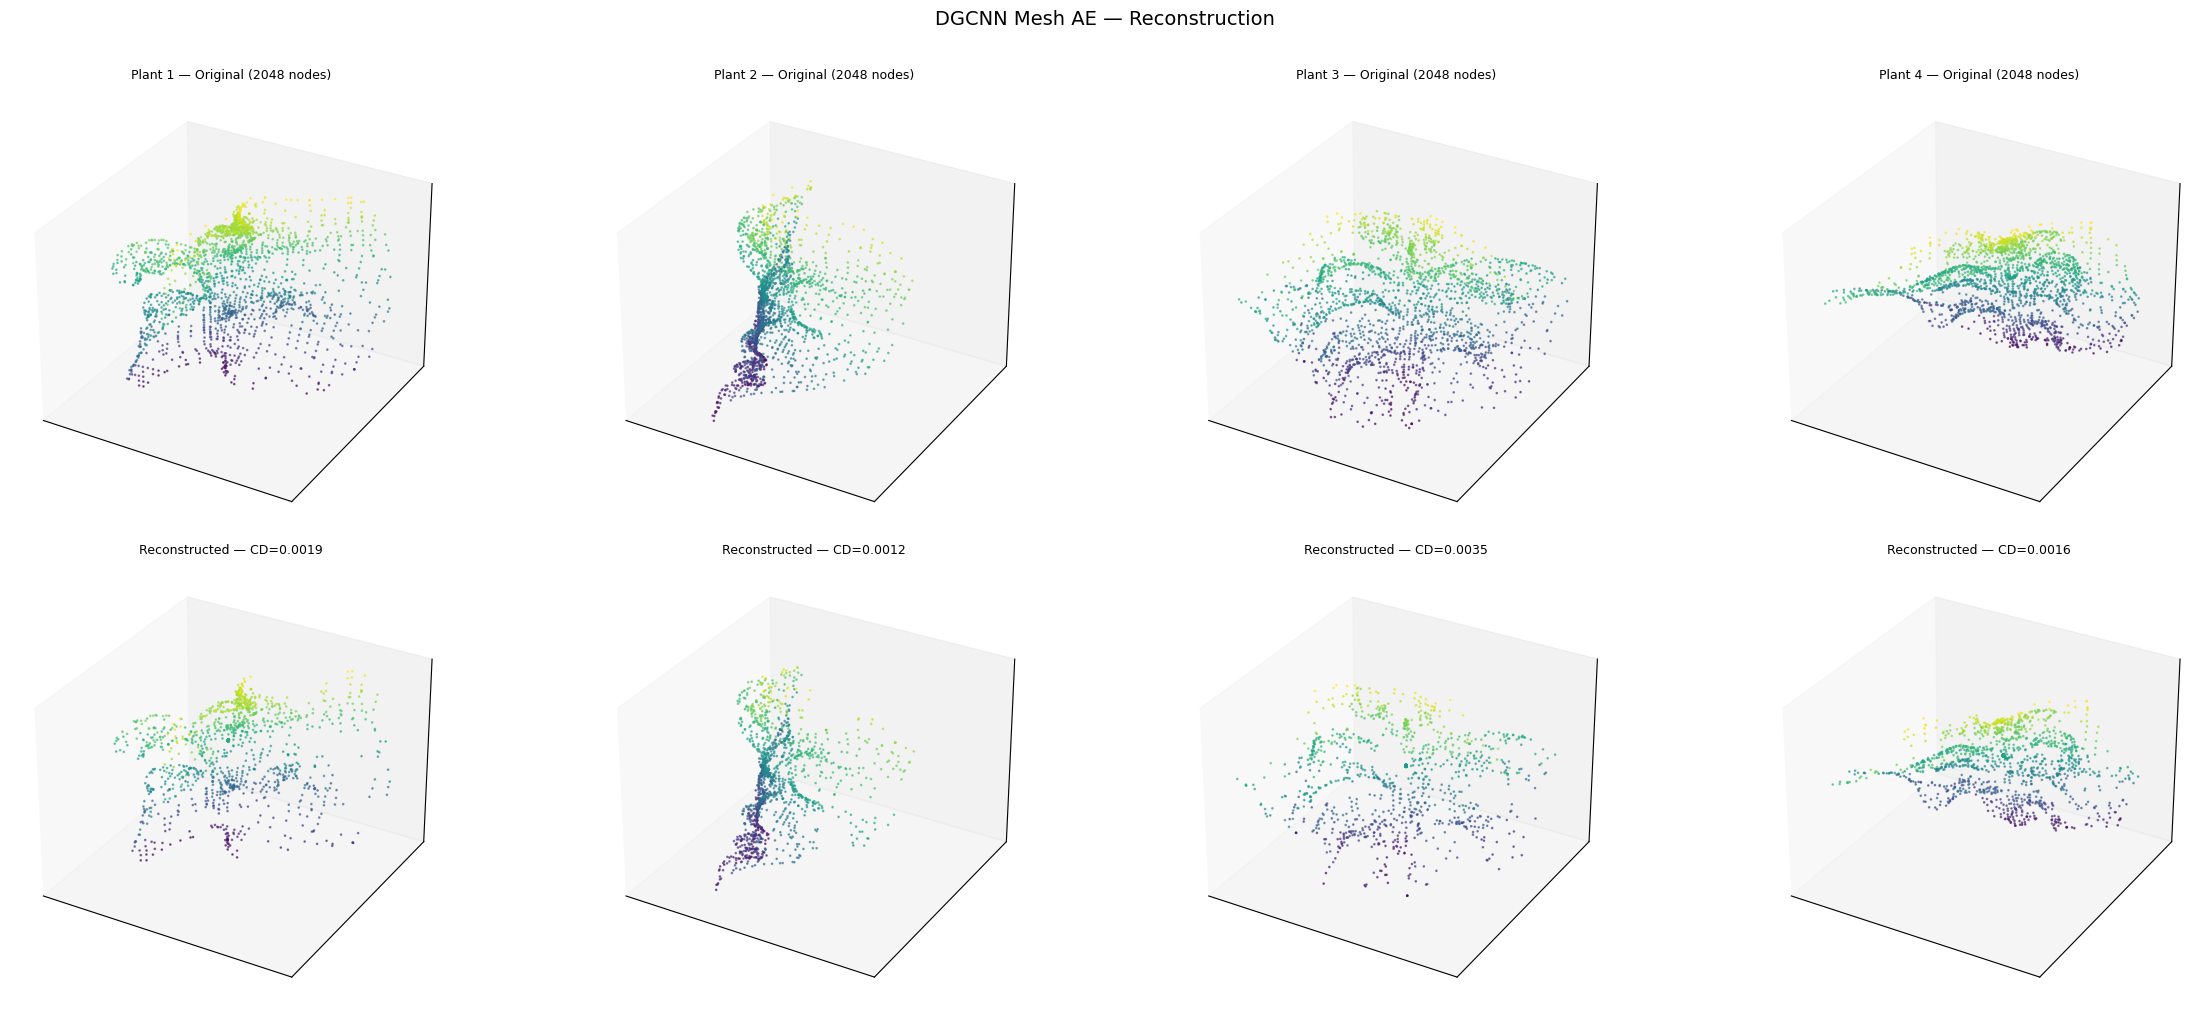

Logged to W&B ✅


epoch,100
lr,1e-05
train/cd,0.00239
val/cd,0.00229


In [ ]:
import wandb

# resume the exact same run — grab run_id from your W&B dashboard
# it looks like: "abc12xyz"
RUN_ID = "ogw6py88"

run = wandb.init(
    project = "maize-dgcnn-mesh-ae-log",
    id      = RUN_ID,
    resume  = "must",       # "must" will error if run_id not found — safer than "allow"
)

# ── generate reconstructions ───────────────────────────────────────────────────
model.load_state_dict(torch.load("best_dgcnn_mesh.pt", map_location=device))
model.eval()

n_show  = min(4, len(val_graphs))
samples = val_graphs[:n_show]

fig = plt.figure(figsize=(6 * n_show, 10))
fig.suptitle("DGCNN Mesh AE — Reconstruction", fontsize=14, y=1.01)

for col, g in enumerate(samples):
    g_dev       = g.clone().to(device)
    g_dev.batch = torch.zeros(g_dev.num_nodes, dtype=torch.long, device=device)

    with torch.no_grad():
        x_hat, _, _ = model(g_dev)

    orig  = g.x.numpy()
    recon = x_hat.cpu().numpy()
    cd    = chamfer(x_hat, g_dev.x).item()

    vmin, vmax = orig[:,2].min(), orig[:,2].max()

    ax1 = fig.add_subplot(2, n_show, col + 1, projection='3d')
    ax1.scatter(orig[:,0], orig[:,1], orig[:,2],
                s=0.8, alpha=0.6, c=orig[:,2], cmap='viridis', vmin=vmin, vmax=vmax)
    ax1.set_title(f"Plant {col+1} — Original ({orig.shape[0]} nodes)", fontsize=9)
    ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

    ax2 = fig.add_subplot(2, n_show, n_show + col + 1, projection='3d')
    ax2.scatter(recon[:,0], recon[:,1], recon[:,2],
                s=0.8, alpha=0.6, c=recon[:,2], cmap='viridis', vmin=vmin, vmax=vmax)
    ax2.set_title(f"Reconstructed — CD={cd:.4f}", fontsize=9)
    ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150, bbox_inches='tight')

# ── log and finish ─────────────────────────────────────────────────────────────
wandb.log({"reconstruction": wandb.Image("reconstruction.png")})
plt.show()
print("Logged to W&B ✅")
wandb.finish()